In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

In [2]:
X_train = [[1,2],[2,3],[3,3],[6,5],[7,7]]
X_test = [[7,6]]
Y_train = [0,0,0,1,1]

In [3]:
df = pd.DataFrame(X_train)

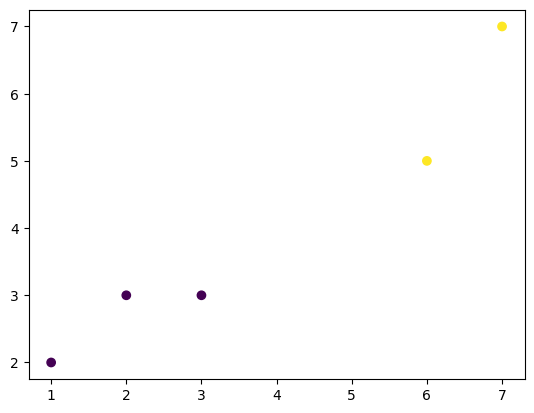

In [4]:
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=Y_train)

In [5]:
class KNN:
    # Constructor of the class
    def __init__(self,k=3):
        self.k = k

    #Store the data
    def fit(self,x,y):
        self.X_train = np.array(x)
        self.Y_train = np.array(y)

    #Calculate Euclidian Distance
    def distance(self,x1,x2):
        d = np.sqrt(np.sum((x1-x2)**2))
        return(d)

    #Predict a single point
    def predict_single(self,x):
        dist = []
        for x_train in self.X_train:
            dist.append(self.distance(x,x_train))
        np.array(dist)

        #Get the index of K nearest neighbour
        k_index = np.argsort(dist)[:self.k]

        #Find the labels
        k_labels = self.Y_train[k_index]

        #Majority Count
        most_common = Counter((k_labels)).most_common(1)
        return(most_common[0][0])
        

In [12]:
knn = KNN(k=3)

In [15]:
knn.fit(X_train,Y_train)

In [16]:
knn.predict_single(X_test)

1

In [13]:
X_test = [[7,6]]

In [17]:
# Homework

In [2]:
from sklearn.datasets import load_iris

In [3]:
X = load_iris().data
Y = load_iris().target

In [6]:
df = pd.DataFrame(X,columns=load_iris().feature_names)

In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
#Setosa, Versicolour,Verginica

In [9]:
X = df.iloc[:,[0,2]]

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=3)

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

In [14]:
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [32]:
predict = np.array([[3.9,4]])

In [33]:
knn.predict(predict)

C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])

In [29]:
from mlxtend.plotting import plot_decision_regions

C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


<Axes: >

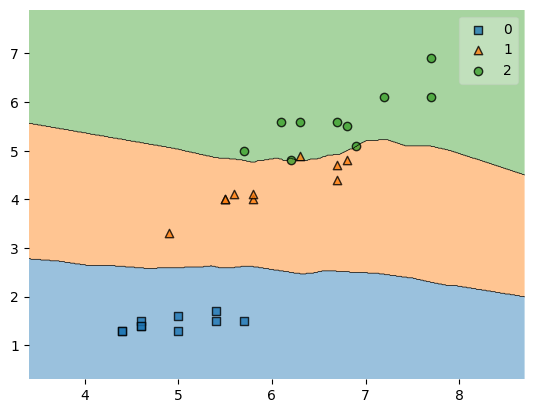

In [31]:
plot_decision_regions(X_test.values,Y_test,knn)

In [29]:
df.size

600

In [30]:
#PCA

In [35]:
df = pd.read_csv("train.csv")

In [36]:
cd C:\Users\arnab\Documents\Python Programming\Datasets

C:\Users\arnab\Documents\Python Programming\Datasets


In [37]:
df.head() #-> MNIST dataset

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
df.shape

(42000, 785)

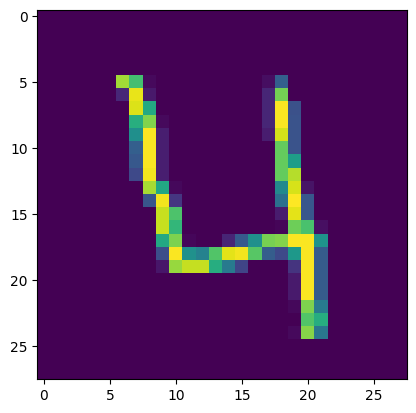

In [39]:
plt.imshow(df.iloc[3,1:].values.reshape(28,28))

In [57]:
X = df.iloc[:,1:]
X = X/255
Y = df.iloc[:,0]

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
knn = KNeighborsClassifier(n_neighbors=5)

In [63]:
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [64]:
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

In [67]:
conf = confusion_matrix(Y_test,knn.predict(X_test))

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

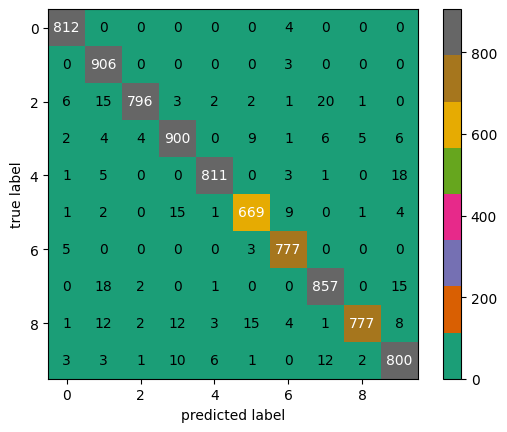

In [68]:
plot_confusion_matrix(conf,colorbar=True,cmap='Dark2')

In [69]:
from sklearn.metrics import accuracy_score

In [70]:
acc = accuracy_score(Y_test,knn.predict(X_test))
print(acc)

0.9648809523809524


In [34]:
# PCA -> for dimentionality reduction

In [42]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]

In [44]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=9)

In [56]:
from sklearn.preprocessing import StandardScaler # -> Standarization

In [49]:
std = StandardScaler()

In [50]:
X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

In [57]:
# PCA

In [58]:
from sklearn.decomposition import PCA

In [59]:
pca = PCA(n_components=100)

In [60]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [64]:
# Calling KNN

In [65]:
knn = KNeighborsClassifier(n_neighbors=5)

In [66]:
knn.fit(X_train_pca,Y_train)

KNeighborsClassifier()

In [67]:
from sklearn.metrics import accuracy_score

In [68]:
acc = accuracy_score(Y_test,knn.predict(X_test_pca))
print(acc)

0.9482142857142857


In [69]:
# How many PCA components are enough?

In [70]:
i=1
acc_new = 0
while True:
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    #Running KNN
    knn.fit(X_train_trf,Y_train)
    acc = accuracy_score(Y_test,knn.predict(X_test_trf))
    #Condition
    if(acc_new>acc):
        break
    else:
        acc_new = acc
        i=i+1
print(i)

16


In [72]:
pca = PCA(n_components=16)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Running KNN
knn.fit(X_train_pca,Y_train)
acc = accuracy_score(Y_test,knn.predict(X_test_pca))
print(acc)

0.9345238095238095


In [73]:
pca = PCA(n_components=784)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [77]:
variance_ratio = np.cumsum(pca.explained_variance_ratio_)

In [81]:
np.where(variance_ratio>=0.90)[0][0] # I should take 225 columns to exaplin 90% of my variance

225

In [82]:
pca = PCA(n_components=225)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Running KNN
knn.fit(X_train_pca,Y_train)
acc = accuracy_score(Y_test,knn.predict(X_test_pca))
print(acc)

0.9403571428571429


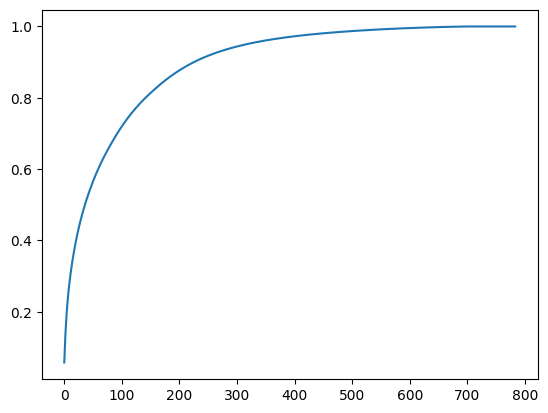

In [83]:
plt.plot(variance_ratio)

In [84]:
#Example 2

In [85]:
df = pd.read_csv("winequality.csv")

In [86]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [101]:
df.dropna(inplace=True)

<Axes: ylabel='count'>

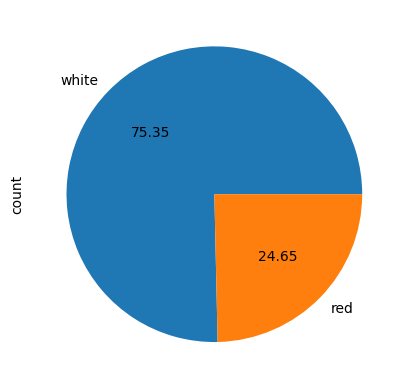

In [102]:
df['type'].value_counts().plot(kind='pie',autopct='%.2f')

In [103]:
X = df.iloc[:,1:]
Y = df.iloc[:,0]

In [105]:
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000,6463.000000
mean,7.217755,0.339589,0.318758,5.443958,0.056056,30.516865,115.694492,0.994698,3.218332,0.531150,10.492825,5.818505
std,1.297913,0.164639,0.145252,4.756852,0.035076,17.758815,56.526736,0.003001,0.160650,0.148913,1.193128,0.873286
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992330,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.997000,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [107]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=4)

In [109]:
from sklearn.preprocessing import LabelEncoder

In [113]:
# Label Encoder can only be used in output columns -> Feature Engg.

In [110]:
lb = LabelEncoder()
Y_train = lb.fit_transform(Y_train)
Y_test = lb.transform(Y_test)

In [114]:
Y_test

array([1, 1, 1, ..., 1, 0, 1])

In [115]:
# H W: Train a KNN model and predict the accuracy of classification and also plot confusion matrix

In [116]:
# H W: Train a KNN model and predict the accuracy of classification and also plot confusion matrix but for 8,6,2 pca components

In [117]:
pwd

'C:\\Users\\arnab\\Documents\\Python Programming\\Datasets'